# 1. Import thư viện

In [1]:
print("[Thông báo] Đang import thư viện...")
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, Dataset, DataLoader
from gensim.models import KeyedVectors
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid') # Giúp biểu đồ có lưới nhìn chuyên nghiệp hơn

# 1. Tải font Roboto về (nếu chưa có)
!wget -q -O Roboto-Regular.ttf https://github.com/googlefonts/roboto/raw/main/src/hinted/Roboto-Regular.ttf

# 2. Đọc đích danh file font và lấy tên gốc của nó
font_path = 'Roboto-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name() # Trích xuất tên chuẩn của font

# 3. GHI ĐÈ cấu hình gốc của cả Matplotlib lẫn Seaborn
plt.rcParams['font.family'] = font_name
sns.set(font=font_name) # Ép Seaborn nhận diện
sns.set_theme(style="white", font=font_name) 

print(f"✅ Đã ép hệ thống dùng font: {font_name}")

print("[Thông báo] Đã thực hiện xong việc import thư viện.")

[Thông báo] Đang import thư viện...
✅ Đã ép hệ thống dùng font: Roboto
[Thông báo] Đã thực hiện xong việc import thư viện.


# 2. Xây dựng Dataset và khởi tạo DataLoader

In [2]:
# 1. Nạp lõi Vector FastText/CBOW
word_vectors = KeyedVectors.load("/kaggle/input/datasets/qucvinhchu/cbowfasttext-word2vec-100/fashion_fasttext_core.kv")
EMBEDDING_DIM = 100 # Số chiều Embedding tuỳ thuộc vào lúc huấn luyện mô hình

# Tạo từ điển map từ chữ sang số (Thêm <PAD> ở vị trí 0 và <UNK> ở vị trí 1)
word2idx = {"<PAD>": 0, "<UNK>": 1}
for word in word_vectors.key_to_index:
    word2idx[word] = len(word2idx)

# Tạo ma trận trọng số để nạp vào Pytorch
vocab_size = len(word2idx)
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, idx in word2idx.items():
    if word in word_vectors:
        embedding_matrix[idx] = word_vectors[word]

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

# 2. Xây dựng Custom Dataset
class FashionReviewDataset(Dataset):
    def __init__(self, xlsx_file, word2idx, max_len=70):
        self.df = pd.read_excel(xlsx_file)
        label_cols = ['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']
        self.df[label_cols] = self.df[label_cols].fillna(0)
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Chuyển chuỗi tokenized thành list các số (index)
        text = str(row['Tokenized_Review']).split()
        indices = [self.word2idx.get(w, self.word2idx["<UNK>"]) for w in text]

        # Padding hoặc Truncating (cắt bớt nếu quá dài, thêm 0 nếu quá ngắn)
        if len(indices) < self.max_len:
            indices += [self.word2idx["<PAD>"]] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        # Lấy nhãn của 5 khía cạnh
        labels = {
            "chat_lieu": row['Chất liệu'],
            "kieu_dang": row['Kiểu dáng'],
            "kich_co": row['Kích cỡ'],
            "gia_ca": row['Giá cả'],
            "dich_vu": row['Dịch vụ']
        }

        return torch.tensor(indices, dtype=torch.long), {k: torch.tensor(v, dtype=torch.long) for k, v in labels.items()}

DATASET_PATH = "/kaggle/input/datasets/qucvinhchu/fashionreviewslabeled-tokenized/Tokenized_Reviews.xlsx"

# Khởi tạo DataLoader
print("[Thông báo] Đang khởi tạo Dataset...")
dataset = FashionReviewDataset(DATASET_PATH, word2idx)

# 1. TÍNH TOÁN KÍCH THƯỚC (90% Train - 10% Val)
total_size = len(dataset)
train_size = int(0.9 * total_size)
val_size = total_size - train_size

# 2. CHIA TÁCH DATASET NGẪU NHIÊN
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"[Thông báo] Tổng số lượng mẫu: {total_size}")
print(f"[Thông báo] Đã chia tập Train: {train_size} mẫu")
print(f"[Thông báo] Đã chia tập Validation: {val_size} mẫu")

# 3. KHỞI TẠO 2 DATALOADER KHÁC NHAU
BATCH_SIZE = 32 # Đặt lại batch_size giống như bạn đang dùng

# Tập Train cần shuffle=True để xáo trộn dữ liệu, tránh học vẹt
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Tập Val KHÔNG CẦN shuffle, chỉ dùng để chấm điểm
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("[Thông báo] Đã thực hiện xong việc khởi tạo Dataset.")

[Thông báo] Đang khởi tạo Dataset...
[Thông báo] Tổng số lượng mẫu: 95145
[Thông báo] Đã chia tập Train: 85630 mẫu
[Thông báo] Đã chia tập Validation: 9515 mẫu
[Thông báo] Đã thực hiện xong việc khởi tạo Dataset.


# 3. Xây dựng kiến trúc mô hình RNN truyền thống

In [3]:
class MultiTaskVanillaRNN(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_classes=4):
        super(MultiTaskVanillaRNN, self).__init__()

        # 1. Lớp nhúng (Embedding Layer)
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False, # Vẫn cho phép tinh chỉnh vector
            padding_idx=0
        )

        # 2. Lõi RNN
        # batch_first=True: Kích thước đầu vào là (batch_size, sequence_length, embedding_dim)
        self.rnn = nn.RNN(
            input_size=embedding_matrix.shape[1], # Lấy số chiều của ma trận Embedding
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            nonlinearity='tanh' # Mặc định của RNN là dùng hàm kích hoạt Tanh
        )

        # 3. Các lớp Phân loại đa nhiệm (5 nhánh)
        self.fc_chat_lieu = nn.Linear(hidden_dim, num_classes)
        self.fc_kieu_dang = nn.Linear(hidden_dim, num_classes)
        self.fc_kich_co = nn.Linear(hidden_dim, num_classes)
        self.fc_gia_ca = nn.Linear(hidden_dim, num_classes)
        self.fc_dich_vu = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x shape: (batch_size, max_len)

        # Chuyển đổi ID từ vựng thành Vector
        embeds = self.embedding(x) # shape: (batch_size, max_len, embedding_dim)

        # Truyền qua mạng RNN
        # rnn_out: Chứa tất cả hidden state ở mọi bước thời gian
        # hidden: Chứa hidden state ở bước thời gian cuối cùng
        rnn_out, hidden = self.rnn(embeds)

        # Lấy trạng thái ẩn cuối cùng (của lớp RNN cuối cùng) làm đại diện cho cả câu
        # hidden shape: (num_layers, batch_size, hidden_dim) --> Lấy layer 0
        sentence_vector = hidden[0, :, :]
        sentence_vector = self.dropout(sentence_vector)

        # Đưa vector câu qua 5 nhánh để dự đoán 5 khía cạnh
        out_chat_lieu = self.fc_chat_lieu(sentence_vector)
        out_kieu_dang = self.fc_kieu_dang(sentence_vector)
        out_kich_co = self.fc_kich_co(sentence_vector)
        out_gia_ca = self.fc_gia_ca(sentence_vector)
        out_dich_vu = self.fc_dich_vu(sentence_vector)

        return out_chat_lieu, out_kieu_dang, out_kich_co, out_gia_ca, out_dich_vu

# 4. Huấn luyện mô hình RNN truyền thống

In [7]:
# Khởi tạo thiết bị và mô hình 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_rnn = MultiTaskVanillaRNN(embedding_matrix, hidden_dim=128, num_classes=4).to(device)

FILE_PATH = "/kaggle/input/datasets/qucvinhchu/fashionreviewslabeled-tokenized/Tokenized_Reviews.xlsx"
df = pd.read_excel(FILE_PATH)
df[['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']] = df[['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']].fillna(0)

# Tính trọng số hàm Weighted Cross-entropy Loss
label_cols = ['Chất liệu', 'Kiểu dáng', 'Kích cỡ', 'Giá cả', 'Dịch vụ']
num_classes = 4
weights_dict = {}

print("[Thông báo] Đang tự động tính toán trọng số cân bằng lớp...")
for col in label_cols:
    # Đếm số lượng mẫu thực tế của từng nhãn (0, 1, 2, 3)
    class_counts = df[col].value_counts().sort_index().values
    total_samples = class_counts.sum()
    
    # Công thức cốt lõi: Inverse Class Frequency (Nghịch đảo tần suất)
    # Trọng số = Tổng số mẫu / (Số lượng lớp * Số mẫu của lớp đó)
    weights = total_samples / (num_classes * class_counts)
    
    # Chuyển đổi thành Tensor để đẩy vào GPU cho PyTorch hiểu
    weights_dict[col] = torch.tensor(weights, dtype=torch.float32).to(device)

# Khởi tạo 5 hàm Loss độc lập tự động nhận trọng số vừa tính
criterion_chat_lieu = nn.CrossEntropyLoss(weight=weights_dict['Chất liệu'])
criterion_kieu_dang = nn.CrossEntropyLoss(weight=weights_dict['Kiểu dáng'])
criterion_kich_co = nn.CrossEntropyLoss(weight=weights_dict['Kích cỡ'])
criterion_gia_ca = nn.CrossEntropyLoss(weight=weights_dict['Giá cả'])
criterion_dich_vu = nn.CrossEntropyLoss(weight=weights_dict['Dịch vụ'])

optimizer = optim.Adam(model_rnn.parameters(), lr=0.001)
EPOCHS = 20

# 1. TẠO MỘT MẢNG ĐỂ LƯU LỊCH SỬ LOSS
history_train_loss = []
history_val_loss = []

print("[Thông báo] Bắt đầu vòng lặp huấn luyện...")

for epoch in range(EPOCHS):
    # PHA 1: HUẤN LUYỆN (TRAIN PHASE)
    model_rnn.train() # Bật chế độ cập nhật trọng số
    total_train_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=True)
    
    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = {k: v.to(device) for k, v in labels.items()}
        
        optimizer.zero_grad()
        preds = model_rnn(inputs)
        
        # Tính Loss
        loss_chat_lieu = criterion_chat_lieu(preds[0], labels["chat_lieu"])
        loss_kieu_dang = criterion_kieu_dang(preds[1], labels["kieu_dang"])
        loss_kich_co = criterion_kich_co(preds[2], labels["kich_co"])
        loss_gia_ca = criterion_gia_ca(preds[3], labels["gia_ca"])
        loss_dich_vu = criterion_dich_vu(preds[4], labels["dich_vu"])
        
        loss = loss_chat_lieu + loss_kieu_dang + loss_kich_co + loss_gia_ca + loss_dich_vu
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        progress_bar.set_postfix({'train_loss': f"{loss.item():.4f}"})
        
    avg_train_loss = total_train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)

    # PHA 2: ĐÁNH GIÁ (VALIDATION PHASE)
    model_rnn.eval() # BẮT BUỘC: Đóng băng Dropout và khóa cập nhật trọng số
    total_val_loss = 0
    
    # BẮT BUỘC: Không tính đạo hàm (no_grad) để tiết kiệm cực nhiều RAM và chạy nhanh hơn
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = {k: v.to(device) for k, v in labels.items()}
            
            preds = model_rnn(inputs)
            
            loss_chat_lieu = criterion_chat_lieu(preds[0], labels["chat_lieu"])
            loss_kieu_dang = criterion_kieu_dang(preds[1], labels["kieu_dang"])
            loss_kich_co = criterion_kich_co(preds[2], labels["kich_co"])
            loss_gia_ca = criterion_gia_ca(preds[3], labels["gia_ca"])
            loss_dich_vu = criterion_dich_vu(preds[4], labels["dich_vu"])
            
            loss = loss_chat_lieu + loss_kieu_dang + loss_kich_co + loss_gia_ca + loss_dich_vu
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    history_val_loss.append(avg_val_loss)
    
    # IN KẾT QUẢ SO SÁNH GIỮA 2 TẬP
    print(f"👉 Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Lưu mô hình
torch.save(model_rnn.state_dict(), "/kaggle/working/multitask_vanilla_rnn.pth")

[Thông báo] Đang tự động tính toán trọng số cân bằng lớp...
[Thông báo] Bắt đầu vòng lặp huấn luyện...


Epoch 1/20 [Train]: 100%|██████████| 2676/2676 [00:23<00:00, 114.89it/s, train_loss=6.8488]


👉 Epoch 1/20 | Train Loss: 6.7716 | Val Loss: 6.8348


Epoch 2/20 [Train]: 100%|██████████| 2676/2676 [00:22<00:00, 116.89it/s, train_loss=6.9633]


👉 Epoch 2/20 | Train Loss: 6.7051 | Val Loss: 6.6039


...

👉 Epoch 18/20 | Train Loss: 6.5072 | Val Loss: 6.5662


Epoch 19/20 [Train]: 100%|██████████| 2676/2676 [00:22<00:00, 117.02it/s, train_loss=6.8597]


👉 Epoch 19/20 | Train Loss: 6.8010 | Val Loss: 6.8592


Epoch 20/20 [Train]: 100%|██████████| 2676/2676 [00:22<00:00, 117.16it/s, train_loss=6.3353]


👉 Epoch 20/20 | Train Loss: 6.6705 | Val Loss: 6.3605


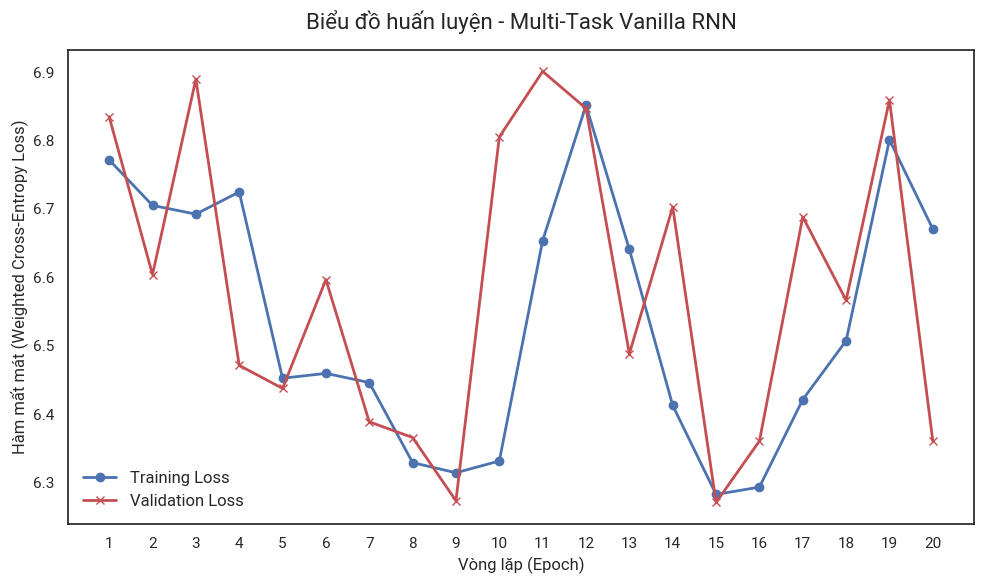

✅ Đã lưu biểu đồ vào file RNN_Training_Loss_Curve.png


<Figure size 640x480 with 0 Axes>

In [8]:
# Thiết lập kích thước và phong cách biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ đường Loss
plt.plot(range(1, EPOCHS + 1), history_train_loss, marker='o', linestyle='-', color='b', linewidth=2, label='Training Loss')
plt.plot(range(1, EPOCHS + 1), history_val_loss, marker='x', linestyle='-', color='r', linewidth=2, label='Validation Loss')

# Trang trí biểu đồ
plt.title('Biểu đồ huấn luyện - Multi-Task Vanilla RNN', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Vòng lặp (Epoch)', fontsize=12)
plt.ylabel('Hàm mất mát (Weighted Cross-Entropy Loss)', fontsize=12)

# Ép trục X chỉ hiện số nguyên (1, 2, 3... 20) thay vì số thập phân (1.5, 2.5)
plt.xticks(range(1, EPOCHS + 1))

plt.legend(fontsize=12)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# Lưu biểu đồ thành file ảnh để chèn vào báo cáo
plt.savefig("/kaggle/working/RNN_Training_Loss_Curve.png", dpi=300, bbox_inches='tight')
print("✅ Đã lưu biểu đồ vào file RNN_Training_Loss_Curve.png")

# 5. Đánh giá mô hình RNN truyền thống

In [9]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# 1. Chuyển mô hình sang chế độ đánh giá
model_rnn.eval()

# 2. Khởi tạo dictionary để lưu trữ dự đoán và nhãn thực tế của 5 khía cạnh
all_preds = {"chat_lieu": [], "kieu_dang": [], "kich_co": [], "gia_ca": [], "dich_vu": []}
all_labels = {"chat_lieu": [], "kieu_dang": [], "kich_co": [], "gia_ca": [], "dich_vu": []}

print("[Thông báo] Đang chạy dữ liệu qua mô hình để đánh giá...")
with torch.no_grad(): # Tắt tính toán đạo hàm để tiết kiệm RAM và tăng tốc
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        
        # Nhận kết quả dự đoán (Dạng Logits: điểm số thô)
        preds = model_rnn(inputs)
        
        # Dùng argmax để biến điểm số thô thành nhãn có điểm cao nhất (0, 1, 2, 3)
        all_preds["chat_lieu"].extend(torch.argmax(preds[0], dim=1).cpu().numpy())
        all_preds["kieu_dang"].extend(torch.argmax(preds[1], dim=1).cpu().numpy())
        all_preds["kich_co"].extend(torch.argmax(preds[2], dim=1).cpu().numpy())
        all_preds["gia_ca"].extend(torch.argmax(preds[3], dim=1).cpu().numpy())
        all_preds["dich_vu"].extend(torch.argmax(preds[4], dim=1).cpu().numpy())
        
        # Lưu lại nhãn thực tế
        all_labels["chat_lieu"].extend(labels["chat_lieu"].numpy())
        all_labels["kieu_dang"].extend(labels["kieu_dang"].numpy())
        all_labels["kich_co"].extend(labels["kich_co"].numpy())
        all_labels["gia_ca"].extend(labels["gia_ca"].numpy())
        all_labels["dich_vu"].extend(labels["dich_vu"].numpy())

print("✅ Đã gom xong kết quả!")

[Thông báo] Đang chạy dữ liệu qua mô hình để đánh giá...
✅ Đã gom xong kết quả!


In [12]:
aspect_keys = ["chat_lieu", "kieu_dang", "kich_co", "gia_ca", "dich_vu"]
aspect_names = ["Chất liệu", "Kiểu dáng", "Kích cỡ", "Giá cả", "Dịch vụ"]
target_names = ["Không có", "Tiêu cực", "Trung tính", "Tích cực"] # Thay đổi theo nhãn thực tế của bạn

for key, name in zip(aspect_keys, aspect_names):
    print(f"\n{'='*50}")
    print(f"BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [{name.upper()}]")
    print(f"{'='*50}")
    print(classification_report(
        all_labels[key], 
        all_preds[key], 
        target_names=target_names,
        zero_division=0
    ))


BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [CHẤT LIỆU]
              precision    recall  f1-score   support

    Không có       0.42      0.60      0.50      3473
    Tiêu cực       0.37      0.06      0.11      2209
  Trung tính       0.28      0.68      0.39      1489
    Tích cực       0.42      0.10      0.16      2344

    accuracy                           0.36      9515
   macro avg       0.37      0.36      0.29      9515
weighted avg       0.39      0.36      0.31      9515


BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [KIỂU DÁNG]
              precision    recall  f1-score   support

    Không có       0.44      0.04      0.07      3117
    Tiêu cực       0.36      0.16      0.22      1819
  Trung tính       0.36      0.75      0.48      1749
    Tích cực       0.37      0.62      0.46      2830

    accuracy                           0.37      9515
   macro avg       0.38      0.39      0.31      9515
weighted avg       0.39      0.37      0.29      9515


BÁO CÁO PHÂN LOẠI: KHÍA CẠNH [KÍCH CỠ]
      

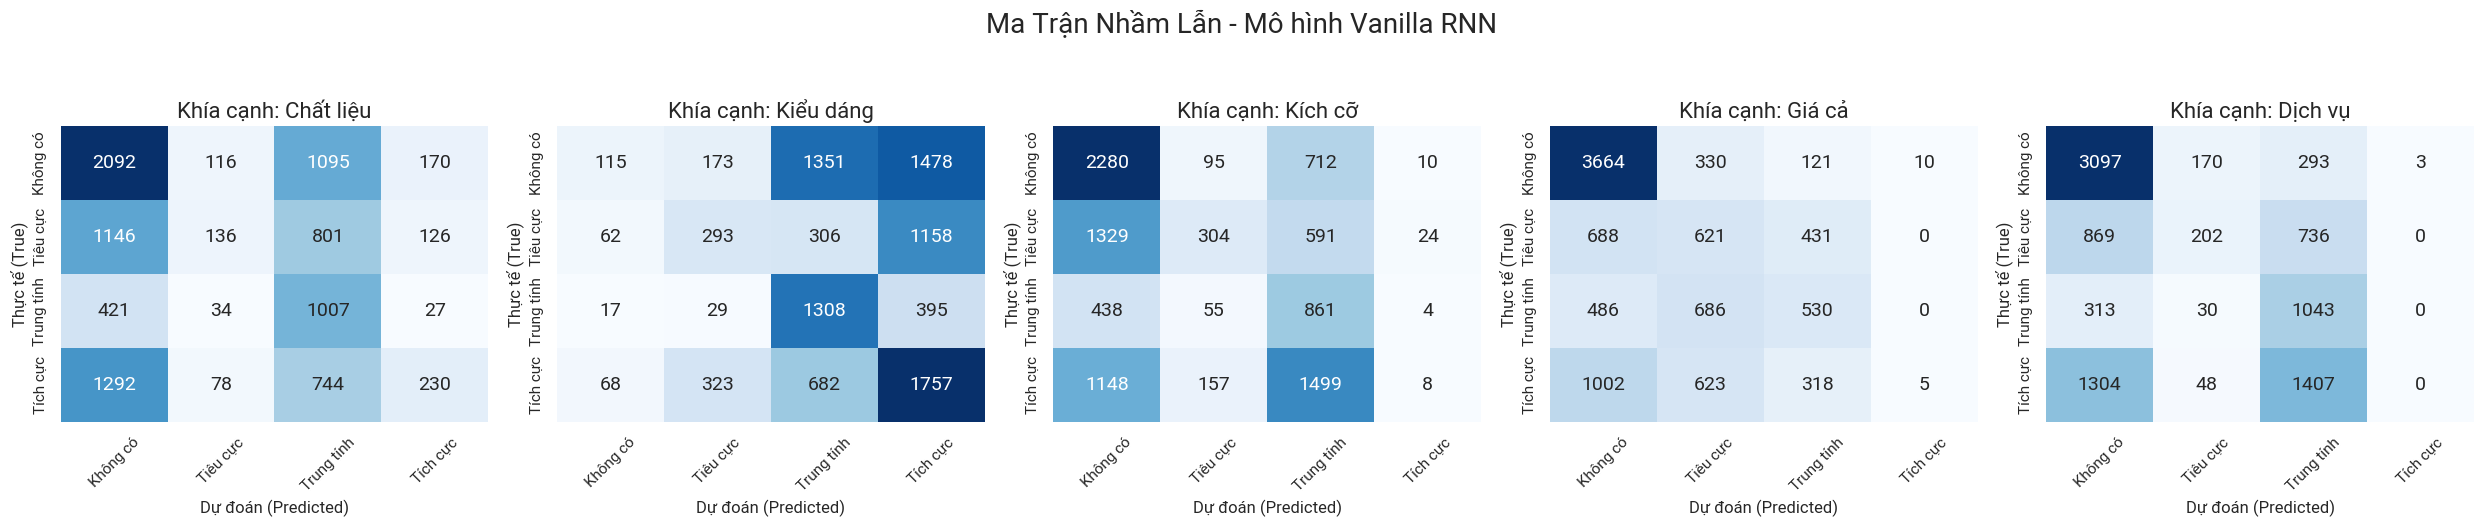

✅ Đã lưu hình ảnh biểu đồ vào file RNN_Confusion_Matrix.png


In [13]:
# Cài đặt kích thước khung hình
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Ma Trận Nhầm Lẫn - Mô hình Vanilla RNN', fontsize=20, fontweight='bold', y=1.05)

for i, (key, name) in enumerate(zip(aspect_keys, aspect_names)):
    # Tính toán Confusion Matrix
    cm = confusion_matrix(all_labels[key], all_preds[key])
    
    # Vẽ biểu đồ bằng Seaborn Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=target_names, yticklabels=target_names,
                cbar=False, annot_kws={"size": 14})
    
    axes[i].set_title(f'Khía cạnh: {name}', fontsize=16)
    axes[i].set_xlabel('Dự đoán (Predicted)', fontsize=12)
    axes[i].set_ylabel('Thực tế (True)', fontsize=12)
    
    # Xoay nhãn trục x để dễ đọc hơn
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Lưu lại hình ảnh này để dán vào Word/Báo cáo
fig.savefig("/kaggle/working/RNN_Confusion_Matrix.png", dpi=300, bbox_inches='tight')
print("✅ Đã lưu hình ảnh biểu đồ vào file RNN_Confusion_Matrix.png")